# 🏥 Health Insurance Claim Prediction

## 📌 Project Overview

This project aims to develop an end-to-end Machine Learning regression model that predicts health insurance claim costs based on customer demographic, lifestyle, and medical information.

The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, model selection, hyperparameter tuning, model evaluation, and deployment using **Streamlit**.

The final solution provides an interactive application that enables users to estimate insurance claim amounts quickly and accurately.

## 📚 Importing Libraries

In this section, we import the essential Python libraries required for data manipulation, visualization, preprocessing, model development, evaluation, and deployment preparation.

These libraries provide the tools needed to efficiently build, train, optimize, and evaluate the machine learning models throughout this project.

In [2]:
import pandas as pd , numpy as np , seaborn as sns , matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler , LabelEncoder ,OrdinalEncoder , PolynomialFeatures , PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold , GridSearchCV , cross_val_score , RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from xgboost import  XGBRegressor
from sklearn.linear_model import  LinearRegression
from sklearn.ensemble import  RandomForestRegressor ,  HistGradientBoostingRegressor
from sklearn.svm import  SVR
import joblib

## 📂 Data Import and Overview

In this section, we load the health insurance dataset and perform an initial exploration to understand its structure, data types, and overall quality. This step helps identify the available features, detect missing values, and gain a general understanding of the dataset before moving on to preprocessing and analysis.

In [3]:
df = pd.read_csv('insurance.csv')

### Dataset Information

We examine the dataset's structure, including the number of observations, data types, and missing values. This helps identify any data quality issues that need to be addressed during preprocessing.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


### Statistical Summary

A statistical summary provides an overview of the dataset by displaying descriptive statistics for both numerical and categorical features. This helps us understand feature distributions, central tendencies, and potential anomalies.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1340.0,670.500000,386.968991,1.00,335.750,670.500,1005.250,1340.00
age,1335.0,38.078652,11.102924,18.00,29.000,38.000,47.000,60.00
bmi,1340.0,30.668955,6.106735,16.00,26.275,30.400,34.700,53.10
bloodpressure,1340.0,94.157463,11.434712,80.00,86.000,92.000,99.000,140.00
children,1340.0,1.093284,1.205334,0.00,0.000,1.000,2.000,5.00
claim,1340.0,13252.745642,12109.609288,1121.87,4719.685,9369.615,16604.305,63770.43


In [6]:
df.describe(include='object').T

,count,unique,top,freq
gender,1340,2,male,678
diabetic,1340,2,No,698
smoker,1340,2,No,1066
region,1337,4,southeast,443


# 📊 Exploratory Data Analysis (EDA)

In this section, we explore the dataset to better understand its characteristics, identify patterns, detect missing values and outliers, and examine relationships between features. This analysis provides valuable insights that guide the data preprocessing and feature engineering steps.

### Duplicate Records

We check for duplicate observations to ensure the dataset does not contain repeated records that could bias the model during training.

In [7]:
df[df.duplicated()]

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim


### Missing Values Analysis

We begin by identifying missing values in each feature to determine whether data imputation or other preprocessing techniques are required before training the machine learning models.

In [8]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

### Numerical Features Distribution

Understanding the distribution of numerical features helps identify skewness, outliers, and unusual patterns that may influence model performance and preprocessing decisions.

In [12]:
num_cols = [x for x in df.columns if x not in cat_cols]

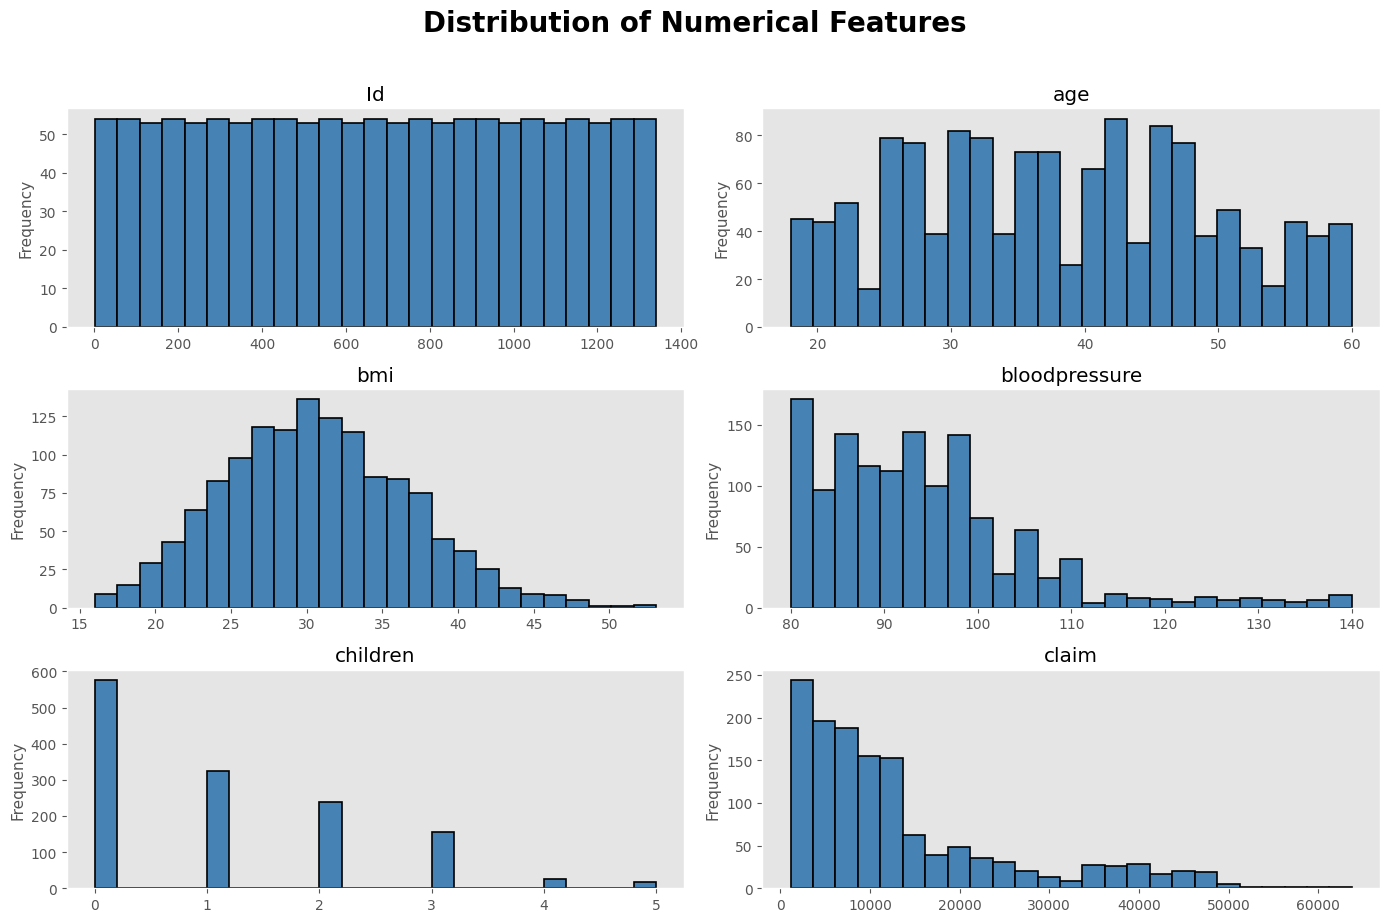

In [13]:
plt.style.use("ggplot")

fig = df[num_cols].hist(
    bins=25,
    figsize=(14, 9),
    color="steelblue",
    edgecolor="black",
    linewidth=1.2,
    grid=False
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

for ax in fig.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

### Categorical Features Analysis

We examine the distribution of categorical variables to understand the frequency of each category and identify any potential class imbalance.

In [11]:
cat_cols = df.select_dtypes(include='object').columns

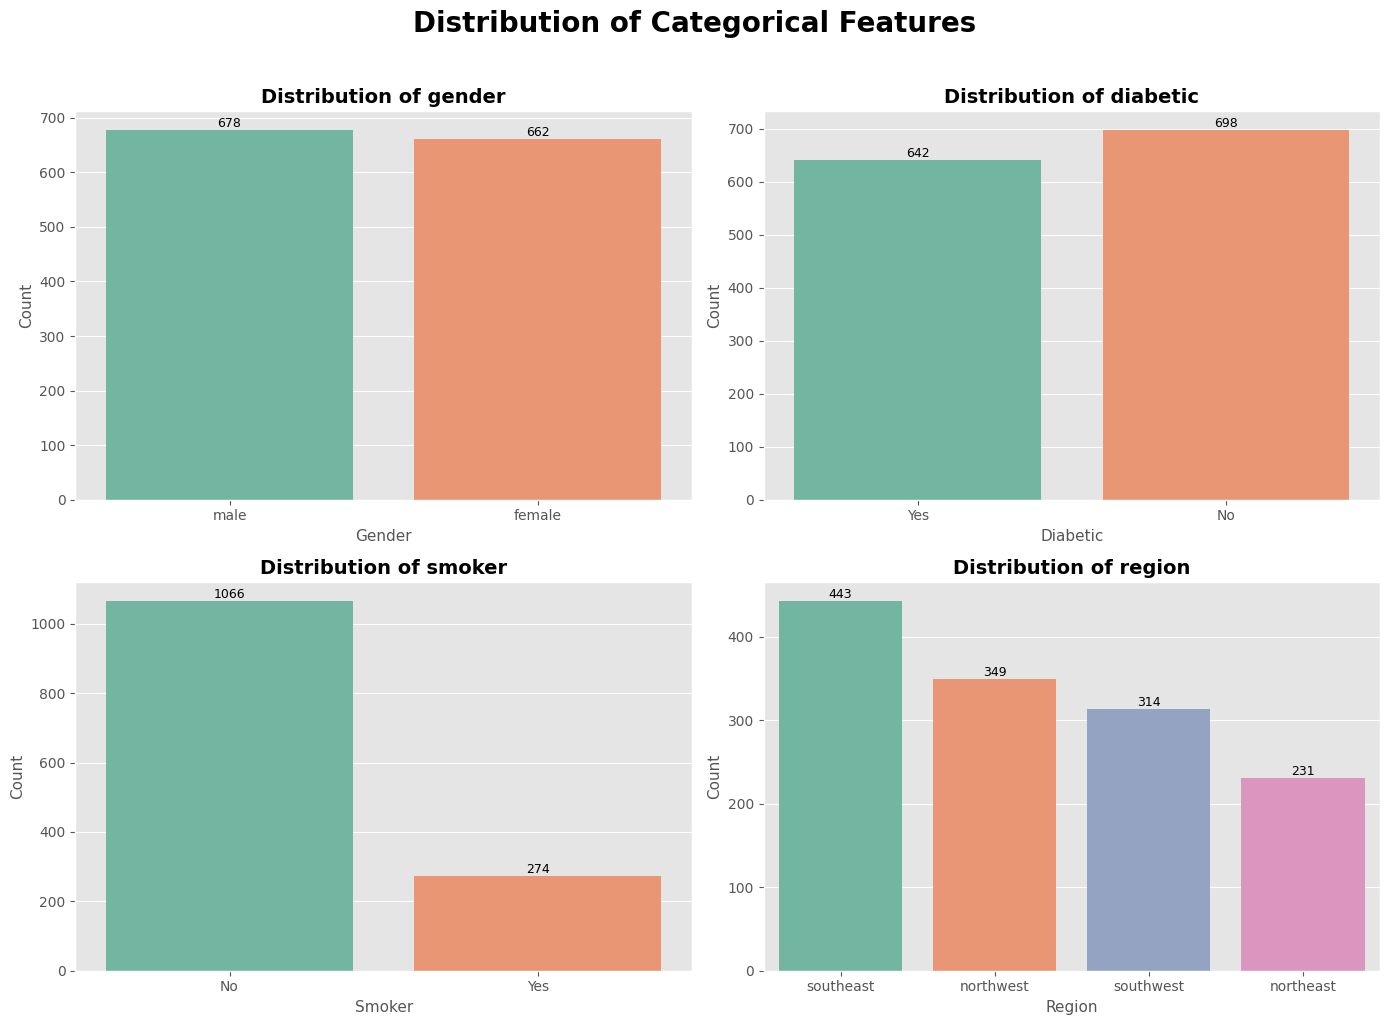

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for ax, col in zip(axes, cat_cols):

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette="Set2",
        legend=False,
        ax=ax
    )

    ax.set_title(
        f"Distribution of {col}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(col.capitalize(), fontsize=11)
    ax.set_ylabel("Count", fontsize=11)

    for container in ax.containers:
        ax.bar_label(container, fontsize=9)

plt.suptitle(
    "Distribution of Categorical Features",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.show()

### Gender and Smoking Status vs. Average Insurance Claim

This visualization compares the average insurance claim across different gender and smoking status groups. By grouping customers based on both features, we can assess the combined effect of gender and smoking behavior on medical expenses.

This analysis helps determine whether smoking has a greater influence on insurance claims than gender and provides valuable insights into the interaction between these two categorical variables.

In [15]:
df.groupby(['gender' , 'smoker'])['claim'].mean().unstack()

smoker,No,Yes
gender,,
female,8762.297367,30678.996261
male,8061.539383,33042.006226


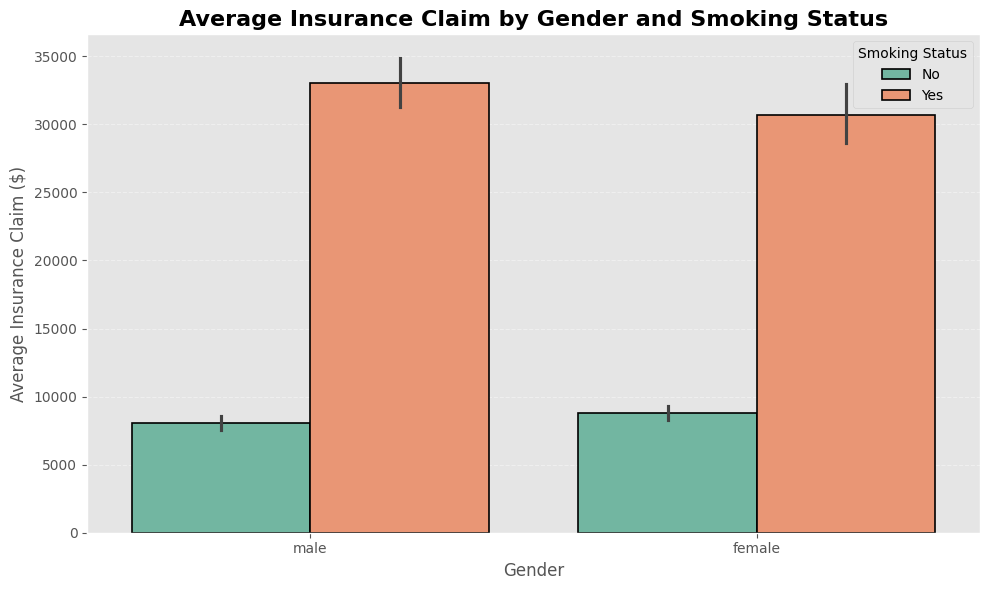

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="gender",
    y="claim",
    hue="smoker",
    estimator="mean",
    palette="Set2",
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Average Insurance Claim by Gender and Smoking Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender", fontsize=12)
plt.ylabel("Average Insurance Claim ($)", fontsize=12)

plt.legend(
    title="Smoking Status",
    frameon=True
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Region and Diabetes Status vs. Average Insurance Claim

This visualization illustrates the average insurance claim across different regions, grouped by diabetes status. It helps identify regional variations in claim costs and assess whether diabetic customers tend to incur higher insurance expenses compared to non-diabetic customers.

In [18]:
pivot_region_diabetic = df.groupby(['region' , 'diabetic'])['claim'].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.861455,16818.302231
northwest,11335.476354,12083.741465
southeast,13578.717200,12521.624633
southwest,13069.907824,12313.739167


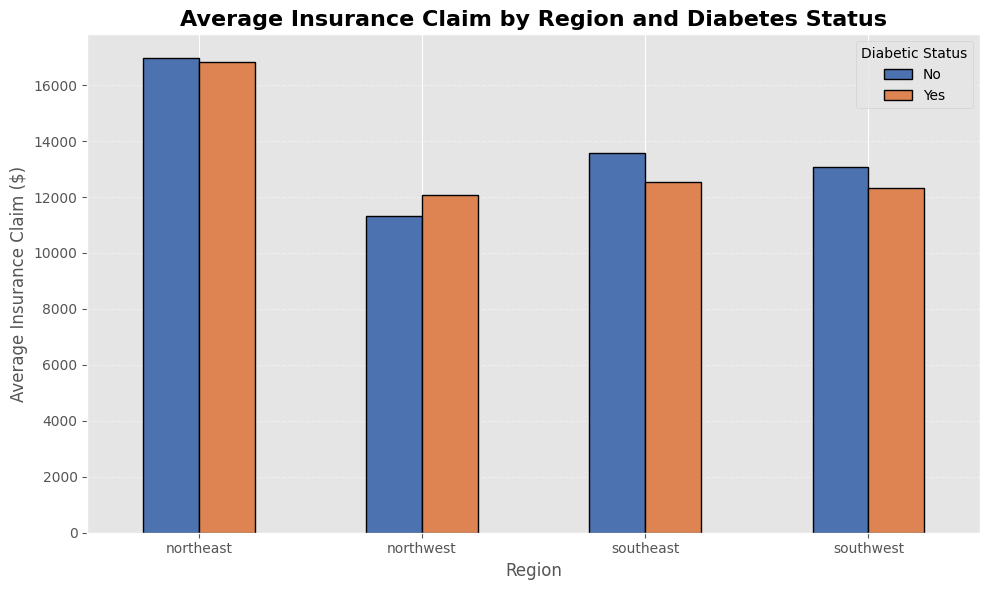

In [19]:
ax = pivot_region_diabetic.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    linewidth=1
)

plt.title(
    "Average Insurance Claim by Region and Diabetes Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region", fontsize=12)
plt.ylabel("Average Insurance Claim ($)", fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    title="Diabetic Status",
    frameon=True
)

plt.tight_layout()

plt.show()

### Regional Analysis by Smoking Status

To further explore the impact of smoking on insurance claims, we calculate the average claim amount for each region while separating smokers and non-smokers using a pivot table.

This summary provides a clear comparison of how insurance costs vary across different geographical regions and helps determine whether the effect of smoking is consistent regardless of location.

In [57]:
pivot_region = pd.pivot_table(df , values= 'claim' , index = 'region' , columns= 'smoker' , aggfunc="mean")
pivot_region

smoker,No,Yes
region,,
northeast,11666.112195,29673.536269
northwest,7980.834055,30192.002759
southeast,7426.223835,34844.997253
southwest,8294.754102,32269.064138


### Number of Children and Diabetes Status vs. Average Insurance Claim

To further investigate the factors influencing insurance costs, we create a pivot table that summarizes the average insurance claim based on the number of children and diabetes status.

This analysis helps identify whether family size and the presence of diabetes are associated with differences in medical expenses, providing additional insights into customer characteristics that may affect insurance claims.

In [58]:
pivot_children = round(pd.pivot_table(df , values= 'claim' , index = 'children' , columns= 'diabetic' , aggfunc="mean"), 2)
pivot_children

diabetic,No,Yes
children,,
0,12846.24,11795.14
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


### Correlation Analysis

A correlation matrix is used to measure the strength of linear relationships between numerical features and the target variable. This helps identify influential features and potential multicollinearity.

Text(0.5, 1.0, 'Correlation Heatmap')

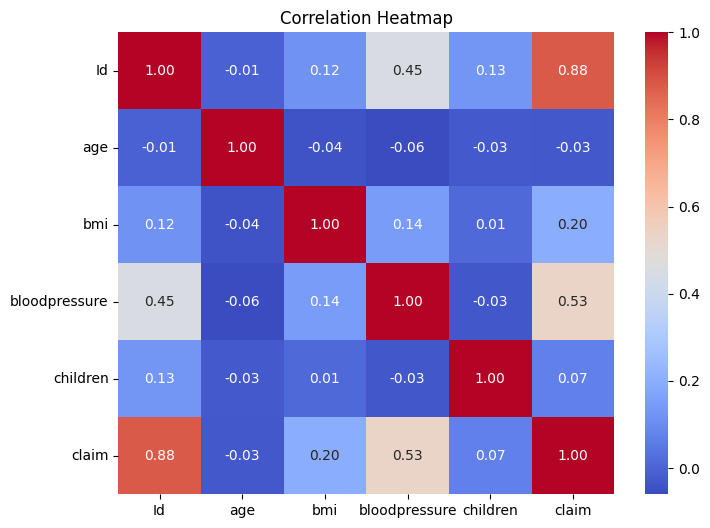

In [59]:
plt.figure(figsize= (8,6))
sns.heatmap(df[num_cols].corr(), annot= True, cmap="coolwarm" , fmt = ".2f")
plt.title("Correlation Heatmap")

# ⚙️ Feature Engineering

Feature engineering is the process of creating new variables from the existing dataset to better capture underlying patterns and relationships.

Rather than generating features arbitrarily, we first analyzed feature importance to identify the variables that contributed most to predicting insurance claim costs. Based on these insights, we engineered interaction and polynomial features that could provide additional information to the machine learning model.

The effectiveness of each engineered feature was evaluated experimentally, and only features that improved model performance were retained.

### Creating Interaction Features

Interaction features combine two or more existing variables to capture relationships that individual features may not fully represent. These features help the model learn more complex patterns within the data.

In [22]:
df["bmi_age"] = df["bmi"] * df["age"]
df["bp_age"] = df["bloodpressure"] * df["age"]
df["bp_bmi"] = df["bloodpressure"] * df["bmi"]

### Creating Polynomial Features

Polynomial features are introduced to capture potential non-linear relationships between numerical variables and the target. Squared terms allow the model to better represent curved trends that cannot be modeled using only the original features.

In [23]:
df["age_squared"] = df["age"] ** 2
df["bmi_squared"] = df["bmi"] ** 2
df["bp_squared"] = df["bloodpressure"] ** 2

### Evaluating Engineered Features

After generating the new features, we retrained the model and compared its performance with the baseline model. This step ensured that each engineered feature contributed meaningful predictive information rather than adding unnecessary complexity.

In [26]:
Target = 'claim'
Features = [x for x in df.columns if x not in (Target ,'Id')] 

X = df[Features]
y = df[Target]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2, random_state=42)

In [29]:
X.select_dtypes(['float' , 'int']).columns

Index(['age', 'bmi', 'bloodpressure', 'children', 'bmi_age', 'bp_age',
       'bp_bmi', 'age_squared', 'bmi_squared', 'bp_squared'],
      dtype='object')

In [30]:
num_colss = ['age', 'bmi', 'bloodpressure', 'children', 'bmi_age', 'bp_age','bp_bmi', 'age_squared', 'bmi_squared', 'bp_squared']
label_cols = ['gender', 'diabetic', 'smoker']
onehot_cols = ['region']

# ⚙️ Data Preprocessing Pipeline

To ensure a consistent and reproducible preprocessing workflow, we use Scikit-learn's **Pipeline** and **ColumnTransformer**.

The preprocessing pipeline automates all data transformation steps, including handling missing values, encoding categorical features, and scaling numerical variables. This approach prevents data leakage by applying all transformations using only the training data during cross-validation and model training.

By integrating preprocessing and model training into a single pipeline, the entire workflow becomes more reliable, maintainable, and easier to deploy.

In [32]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
]) 



label_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])


onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])


preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_colss),
    ('label', label_pipeline, label_cols),
    ('onehot', onehot_pipeline, onehot_cols)
] ,  
  remainder='drop')  # To Avoid Data Leakage

### Building the Machine Learning Pipeline

Finally, the preprocessing workflow is combined with the machine learning model into a single pipeline.

This integrated pipeline guarantees that every new dataset undergoes the exact same preprocessing steps before prediction, reducing the risk of inconsistencies between training and deployment.

In [33]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())])


pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

pipe_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])

pipe_hgb = Pipeline ([
    ('preprocessor', preprocessor),
    ('model' , HistGradientBoostingRegressor())
])

# 🤖 Model Selection

Selecting the most appropriate machine learning algorithm is a crucial step in building a reliable predictive model. Rather than relying on a single algorithm, we evaluate multiple regression models to compare their predictive performance on the same dataset.

Each model is trained using the same preprocessing pipeline, ensuring a fair comparison by applying identical data transformations. The models are then assessed using cross-validation to identify the one that provides the best balance between accuracy and generalization.

The regression models evaluated in this project are:

- **Random Forest Regressor**
- **Linear Regression**
- **XGBoost Regressor**
- **Support Vector Regressor (SVR)**
- **Histogram Gradient Boosting Regressor**

In [70]:
models = {
    'Random Forest': pipe_rf,
    'Linear Regression': pipe_lr,
    'XGBoost': pipe_xgb,
    'SVM': pipe_svm,
    'hgb' : pipe_hgb
}

### Model Evaluation using Cross-Validation

To compare the performance of the candidate models, we use **5-Fold Cross-Validation** with the **R² score** as the evaluation metric.

Cross-validation provides a more reliable estimate of model performance by repeatedly training and validating each model on different subsets of the training data. This approach reduces the risk of selecting a model based on a favorable train-test split and helps evaluate its ability to generalize to unseen data.

In [71]:
results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='r2'
    )

    results[name] = scores

    print(f'{name}:')
    print(f'CV Scores: {scores}')
    print(f'Mean R²: {scores.mean():.4f}')
    print('-' * 50)

Random Forest:
CV Scores: [0.77495408 0.74088501 0.80223127 0.78672948 0.80467375]
Mean R²: 0.7819
--------------------------------------------------
Linear Regression:
CV Scores: [0.66751199 0.63235716 0.72767869 0.66083136 0.74165301]
Mean R²: 0.6860
--------------------------------------------------
XGBoost:
CV Scores: [0.73433269 0.71643528 0.76196891 0.7226149  0.76924844]
Mean R²: 0.7409
--------------------------------------------------
SVM:
CV Scores: [-0.09874453 -0.05566908 -0.09788086 -0.1058742  -0.1228104 ]
Mean R²: -0.0962
--------------------------------------------------
hgb:
CV Scores: [0.77679111 0.72629588 0.78807039 0.75955798 0.79609125]
Mean R²: 0.7694
--------------------------------------------------


# 🔍 Overfitting Analysis

After selecting the best-performing model, we evaluate its ability to generalize by comparing its performance on the training and validation sets using 5-Fold Cross-Validation.

By examining both the training and validation **R² scores**, we can determine whether the model is:

- **Well-generalized:** Similar training and validation scores.
- **Overfitting:** Training performance is significantly higher than validation performance.
- **Underfitting:** Both training and validation performance are relatively low.

This analysis helps assess the model's learning behavior before proceeding to hyperparameter optimization.

In [34]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    pipe_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    return_train_score=True
)

print("Train R²:", cv_results['train_score'])
print("Validation R²:", cv_results['test_score'])

print("Mean Train R²:",
      cv_results['train_score'].mean())

print("Mean Validation R²:",
      cv_results['test_score'].mean())

Train R²: [0.97056628 0.97183053 0.96977357 0.97084951 0.96821499]
Validation R²: [0.77571108 0.73825549 0.80491098 0.79079365 0.8077124 ]
Mean Train R²: 0.9702469763454917
Mean Validation R²: 0.7834767188731749


### Interpretation

The comparison between the training and validation scores provides insight into the model's generalization performance.

A small difference between the two scores indicates that the model generalizes well to unseen data. Conversely, a large performance gap suggests overfitting, meaning the model has learned patterns specific to the training data that do not generalize effectively.

This evaluation guides the decision to perform hyperparameter tuning to improve the model's robustness.

### Defining the Hyperparameter Search Space

Before performing the search, we define a range of candidate values for the most important Random Forest hyperparameters. During optimization, RandomizedSearchCV randomly samples combinations from this search space and evaluates each configuration using cross-validation.

In [35]:
param_distributions = {
    'model__n_estimators' : [10 , 20 , 40 , 80 , 150 , 200 , 300],
    'model__criterion' : ['poisson', 'absolute_error', 'squared_error'],
    'model__max_depth' : [1, 2 , 4 , 8  , 10 , 12 , 15 , 20],
    'model__min_samples_split' : [2, 4, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 1.0]
}

### Randomized Hyperparameter Search

We perform hyperparameter optimization using **RandomizedSearchCV** with 5-fold cross-validation.

For each randomly selected hyperparameter combination, the model is trained and validated across multiple folds using the **R² score** as the evaluation metric.

The configuration that achieves the highest average validation performance is selected as the final optimized model.

In [36]:
Randomized_Search = RandomizedSearchCV(
    estimator= pipe_rf,
    n_iter= 500 , 
    param_distributions = param_distributions,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose= 1,
    refit=  True
)

Randomized_Search.fit(X_train, y_train)


Fitting 5 folds for each of 500 candidates, totalling 2500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__criterion': ['poisson', 'absolute_error', ...], 'model__max_depth': [1, 2, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",500
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at t

### Best Hyperparameter Configuration

After completing the search, we retrieve the hyperparameter combination that achieved the highest cross-validation score. This optimized configuration is then used as the final Random Forest model for evaluation on the unseen test set.

In [37]:
print("Best CV R²:", Randomized_Search.best_score_)
print("Best Parameters:")

for param, value in Randomized_Search.best_params_.items():
    print(f"{param}: {value}")

Best CV R²: 0.8002254563444737
Best Parameters:
model__n_estimators: 200
model__min_samples_split: 10
model__min_samples_leaf: 2
model__max_features: 1.0
model__max_depth: 4
model__criterion: poisson


### Hyperparameter Optimization Outcome

The optimized Random Forest model achieved a higher cross-validation score than the baseline model, indicating improved generalization performance. The tuned hyperparameters help balance model complexity and predictive accuracy, resulting in a more robust model for estimating health insurance claim costs.

In [38]:
print("Before:", 0.7819 )
print("After :", Randomized_Search.best_score_)

Before: 0.7819
After : 0.8002254563444737


In [39]:
best_rf = Randomized_Search.best_estimator_

In [40]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    return_train_score=True
)

print("Train R²:", cv_results['train_score'])
print("Validation R²:", cv_results['test_score'])

print("Mean Train R²:",
      cv_results['train_score'].mean())

print("Mean Validation R²:",
      cv_results['test_score'].mean())

Train R²: [0.82995494 0.83845621 0.82386238 0.82917023 0.82135292]
Validation R²: [0.79087437 0.74811563 0.82857917 0.80193649 0.83162162]
Mean Train R²: 0.828559335440801
Mean Validation R²: 0.8002254563444737


# 📈 Final Model Evaluation

After identifying the optimal hyperparameter configuration, we evaluate the final Random Forest model on the held-out test set.

Unlike the training and validation data, the test set has not been used during model development or hyperparameter tuning. Therefore, its performance provides an unbiased estimate of the model's ability to generalize to unseen data.

The model is assessed using three standard regression metrics:

- **R² Score:** Measures the proportion of variance in the target variable explained by the model.
- **Mean Absolute Error (MAE):** Represents the average magnitude of prediction errors.
- **Root Mean Squared Error (RMSE):** Measures the typical prediction error while assigning greater weight to larger errors.

In [41]:
best_rf = Randomized_Search.best_estimator_

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

### Performance Metrics

To evaluate the predictive performance of the optimized model, we calculate three widely used regression metrics. Together, these metrics provide a comprehensive assessment of the model's accuracy, average prediction error, and overall generalization capability.

In [42]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Test R²:", test_r2)
print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)

Test R²: 0.8529282357963307
Test MAE: 3624.8912113846145
Test RMSE: 4915.635893203131


# 📉 Learning Curve Analysis

To further assess the model's learning behavior, we generate a **learning curve**, which compares the training and validation performance as the size of the training dataset increases.

A learning curve helps determine whether the model is:

- **Overfitting:** High training performance but significantly lower validation performance.
- **Underfitting:** Both training and validation scores remain relatively low.
- **Well-Generalized:** Training and validation curves converge with a small performance gap.

This analysis also indicates whether collecting additional training data is likely to improve the model's predictive performance.

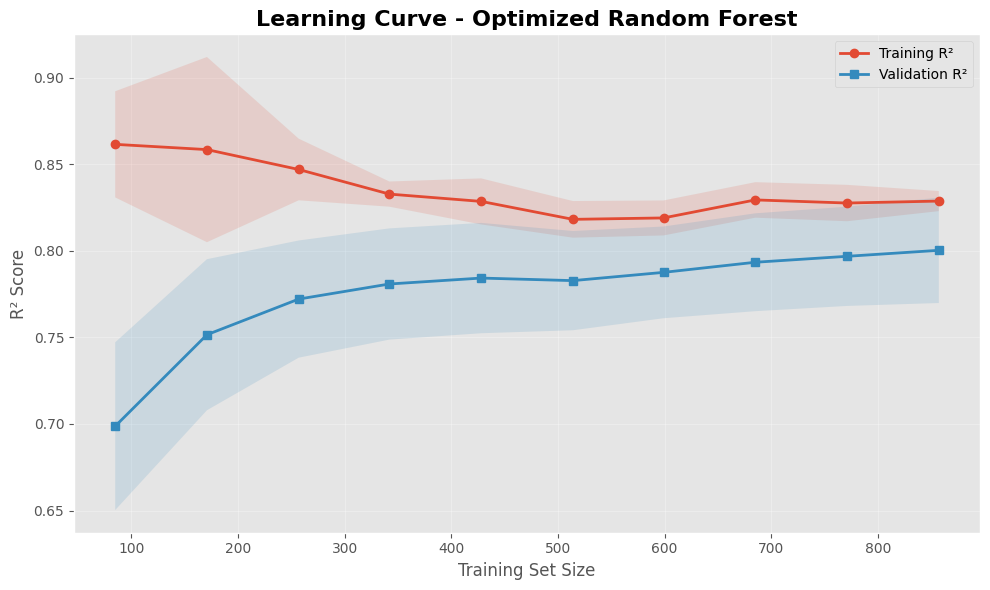

In [43]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, validation_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linewidth=2,
    label='Training R²'
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='s',
    linewidth=2,
    label='Validation R²'
)

plt.fill_between(
    train_sizes,
    train_scores.mean(axis=1)-train_scores.std(axis=1),
    train_scores.mean(axis=1)+train_scores.std(axis=1),
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_scores.mean(axis=1)-validation_scores.std(axis=1),
    validation_scores.mean(axis=1)+validation_scores.std(axis=1),
    alpha=0.15
)

plt.grid(alpha=0.3)
plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.title(
    "Learning Curve - Optimized Random Forest",
    fontsize=16,
    fontweight="bold"
)
plt.legend()
plt.tight_layout()
plt.show()

### Learning Curve Statistics

To complement the learning curve visualization, we display the numerical training and validation **R² scores** for each training set size.

These values provide a detailed view of how the model's performance evolves as more training samples become available. Observing the trend in both scores helps assess the model's learning behavior, detect potential overfitting or underfitting, and determine whether additional training data is likely to improve performance.

In [44]:
train_sizes = np.linspace(0.1, 1.0, 20)

In [45]:
train_sizes, train_scores, validation_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=train_sizes,
    n_jobs=-1
)

In [46]:
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

for size, train, val in zip(
    train_sizes,
    train_mean,
    validation_mean
):
    print(
        f"Samples: {int(size):4d} | "
        f"Train R²: {train:.4f} | "
        f"Validation R²: {val:.4f}"
    )

Samples:   85 | Train R²: 0.8616 | Validation R²: 0.6987
Samples:  126 | Train R²: 0.8859 | Validation R²: 0.7452
Samples:  166 | Train R²: 0.8649 | Validation R²: 0.7541
Samples:  207 | Train R²: 0.8457 | Validation R²: 0.7701
Samples:  248 | Train R²: 0.8473 | Validation R²: 0.7750
Samples:  288 | Train R²: 0.8483 | Validation R²: 0.7786
Samples:  329 | Train R²: 0.8357 | Validation R²: 0.7813
Samples:  369 | Train R²: 0.8336 | Validation R²: 0.7820
Samples:  410 | Train R²: 0.8244 | Validation R²: 0.7841
Samples:  451 | Train R²: 0.8244 | Validation R²: 0.7842
Samples:  491 | Train R²: 0.8180 | Validation R²: 0.7829
Samples:  532 | Train R²: 0.8149 | Validation R²: 0.7841
Samples:  572 | Train R²: 0.8154 | Validation R²: 0.7860
Samples:  613 | Train R²: 0.8203 | Validation R²: 0.7909
Samples:  654 | Train R²: 0.8289 | Validation R²: 0.7928
Samples:  694 | Train R²: 0.8303 | Validation R²: 0.7948
Samples:  735 | Train R²: 0.8293 | Validation R²: 0.7952
Samples:  775 | Train R²: 0.828

# 📊 Error Analysis

After evaluating the overall performance of the optimized model, we perform an error analysis to better understand where prediction errors occur.

Rather than relying solely on aggregate evaluation metrics, error analysis investigates how prediction accuracy varies across different customer groups and feature values. This helps identify patterns in the model's strengths and weaknesses, uncover potential sources of bias, and highlight opportunities for future improvements.

In [86]:
best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

In [87]:
errors = X_test.copy()

errors['actual'] = y_test
errors['predicted'] = y_pred
errors['residual'] = y_test - y_pred
errors['abs_error'] = abs(errors['residual'])

errors.sort_values(
    'abs_error',
    ascending=False
).head(20)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,actual,predicted,residual,abs_error
1190,29.0,female,37.5,106,Yes,2,No,northwest,33471.97,13001.443077,20470.526923,20470.526923
1151,52.0,female,24.1,84,Yes,1,No,southwest,26236.58,6704.528192,19532.051808,19532.051808
1165,22.0,male,36.1,80,No,3,No,southwest,27941.29,8734.566194,19206.723806,19206.723806
1132,46.0,male,27.6,84,No,0,No,southwest,24603.05,6535.652083,18067.397917,18067.397917
1112,22.0,male,33.1,91,No,0,No,southwest,23082.96,6560.349067,16522.610933,16522.610933
1144,47.0,female,27.4,80,No,0,No,northeast,25656.58,9572.956075,16083.623925,16083.623925
1087,44.0,male,29.6,91,Yes,0,No,southwest,21232.18,6542.008802,14690.171198,14690.171198
1335,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40,40563.471796,14571.928204,14571.928204
1074,47.0,male,29.8,89,Yes,0,No,southwest,20420.60,6535.652083,13884.947917,13884.947917
1334,43.0,male,32.8,125,No,0,Yes,southwest,52590.83,38732.477541,13858.352459,13858.352459


In [88]:
errors.groupby('smoker')['abs_error'].mean()

smoker
No     3666.802686
Yes    3473.788160
Name: abs_error, dtype: float64

In [89]:
errors.groupby('smoker').apply(
    lambda x: r2_score(x['actual'], x['predicted'])
)

C:\Users\amiir\AppData\Local\Temp\ipykernel_14528\1018075174.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  errors.groupby('smoker').apply(


smoker
No     0.209792
Yes    0.842786
dtype: float64

### Interpretation

The average prediction error is similar for smokers and non-smokers, indicating that the model predicts claim amounts with comparable accuracy for both customer groups.

This suggests that the model is not systematically favoring one smoking category over the other.

# 💾 Model Serialization

Once the optimized Random Forest model has been trained and evaluated, the final step is to save both the trained model and the preprocessing pipeline for future use.

Using **Joblib**, we serialize the fitted model and preprocessing pipeline into `.pkl` files. This allows the exact same preprocessing steps and trained model to be loaded later without retraining, ensuring consistent predictions during deployment.

Saving these artifacts is a standard practice in machine learning workflows and enables seamless integration into production environments, such as the Streamlit web application developed in this project.

In [48]:
top_model = best_rf

In [49]:
top_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','gender','bmi',...,'age_squared','bmi_squared','bp_squared']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('label', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [95]:
joblib.dump(top_model , "best_model.pkl")

['best_model.pkl']

In [96]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [50]:
fitted_preprocessor = top_model.named_steps['preprocessor']

for name, transformer, columns in fitted_preprocessor.transformers_:
    print(f"\n{name}:")
    print(columns)


num:
['age', 'bmi', 'bloodpressure', 'children', 'bmi_age', 'bp_age', 'bp_bmi', 'age_squared', 'bmi_squared', 'bp_squared']

label:
['gender', 'diabetic', 'smoker']

onehot:
['region']


### Saved Model Artifacts

The following files were generated:

- **best_model.pkl** — Contains the optimized Random Forest model trained on the complete training dataset.
- **preprocessor.pkl** — Contains the fitted preprocessing pipeline, including feature scaling and categorical encoding.

These files are loaded directly by the deployment application to ensure that incoming user data is processed identically to the training data before generating predictions.